In [4]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.special import digamma, polygamma
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution
from GASModels.distributions.za_gb2_log_link import ZAGB2LogLinkDistribution

In [5]:
import numpy as np
from scipy.special import expit
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution

## Getting more years for monthly series

In [85]:
INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\treated"
OUTPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab monthly"

for i in range(3, 8):
    df = pd.read_csv(os.path.join(INPUT, os.listdir(INPUT)[i]), sep=",")
    df['year'] = pd.to_datetime(df['Data Medicao'], format = '%Y-%m-%d').dt.year
    df['month'] = pd.to_datetime(df['Data Medicao'], format = '%Y-%m-%d').dt.month
    df['year-month'] = pd.to_datetime(df['Data Medicao'], format = '%Y-%m-%d').dt.strftime("%Y-%m")
    df = df[~df['year'].isin(df.groupby(df['year'])['precipitation original'].apply(lambda x: x.isna().sum()) > 74)]
    df['precipitation original'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].str.replace(",", ".").astype(float).values
    
    if len(df['year'].unique()) >= 18:
    
        df_test = df[df['year'].isin(df['year'].unique()[-3:])]
        df_train = df[~df['year'].isin(df['year'].unique()[-3:])]
        df_train.to_csv(os.path.join(OUTPUT, os.listdir(INPUT)[i].split(".")[0] + "_train.csv"), index = False)
        df_test.to_csv(os.path.join(OUTPUT, os.listdir(INPUT)[i].split(".")[0] + "_test.csv"), index = False)
        



In [86]:
INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\treated"
OUTPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab monthly"

for i in range(3):
    df = pd.read_csv(os.path.join(INPUT, os.listdir(INPUT)[i]), sep=";")
    df['year'] = pd.to_datetime(df['Data Medicao'], format = '%d/%m/%Y').dt.year
    df['month'] = pd.to_datetime(df['Data Medicao'], format = '%d/%m/%Y').dt.month
    df['year-month'] = pd.to_datetime(df['Data Medicao'], format = '%d/%m/%Y').dt.strftime("%Y-%m")
    df = df[~df['year'].isin(df.groupby(df['year'])['precipitation original'].apply(lambda x: x.isna().sum()) > 74)]
    df['precipitation original'].fillna(df['smoothed'], inplace=True)
    
    if len(df['year'].unique()) >= 18:
    
        df_test = df[df['year'].isin(df['year'].unique()[-3:])]
        df_train = df[~df['year'].isin(df['year'].unique()[-3:])]
        df_train.to_csv(os.path.join(OUTPUT, os.listdir(INPUT)[i].split(".")[0] + "_train.csv"), index = False)
        df_test.to_csv(os.path.join(OUTPUT, os.listdir(INPUT)[i].split(".")[0] + "_test.csv"), index = False)

C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\1551914727.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['precipitation original'].fillna(df['smoothed'], inplace=True)
C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\1551914727.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['9,923488149' '-0,09374049']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['precipitation original'].fill

In [6]:
dfs = []
INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\treated"
OUTPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab monthly"

for i, f in enumerate(os.listdir(OUTPUT)):
    if "_train" in f:
        df = pd.read_csv(os.path.join(OUTPUT, f), sep=";")
        if "precipitation original" in df.columns:
            df['precipitation original'].fillna(df['smoothed'].str.replace(",", ".").astype(float).apply(lambda x: x if x > 0 else 0), inplace=True)
        else:
            df = pd.read_csv(os.path.join(OUTPUT, f), sep=",")
            df['precipitation original'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].str.replace(",", ".").astype(float).values
            df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).values
            df['precipitation original'].fillna(df['smoothed'].apply(lambda x: x if x > 0 else 0), inplace=True)
        dfs.append(df)

C:\Users\ilang\AppData\Local\Temp\ipykernel_45096\2618812785.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['precipitation original'].fillna(df['smoothed'].apply(lambda x: x if x > 0 else 0), inplace=True)
C:\Users\ilang\AppData\Local\Temp\ipykernel_45096\2618812785.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we

In [104]:
len(dfs)

6

0       2000
1       2000
2       2000
3       2000
4       2000
        ... 
8786    2026
8787    2026
8788    2026
8789    2026
8790    2026
Name: year, Length: 8791, dtype: int32

In [36]:
df = df[~df['year'].isin(df.groupby(df['year'])['precipitation original'].apply(lambda x: x.isna().sum()) > 74)]
df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).apply(lambda x: x if x > 0 else 0).values

In [37]:
df['precipitation original'].fillna(df['smoothed'], inplace=True)

C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\3015750342.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['precipitation original'].fillna(df['smoothed'], inplace=True)


In [27]:
df['year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2016, 2017, 2018], dtype=int32)

## Models

In [46]:
y = df['precipitation original'].values

In [47]:
theta0 = np.concatenate([
    np.array([
        np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
        0.5,        # c_phi
        0.95,       # alpha_phi
        0.01,       # kappa_phi
        0.01,       # kappa_gamma_phi

        -1.0,       # omega0
        0.5,        # rho

        0.01, 0.01, 0.01,   # omega_y (K=3)

        1.2,        # gamma
        1.2,        # xi
        5.0         # zeta
    ]),
    np.zeros(12)        # gamma0_phi
])

bounds = [
    (-2.0, 4.0),     # mu0_phi
    (0.0, 5.0),      # c_phi
    (0.00, 0.995),   # alpha_phi
    (1e-4, 0.1),     # kappa_phi
    (1e-4, 0.1),     # kappa_gamma_phi

    (-10.0, 2.0),    # omega0
    (0.00, 0.99),   # rho

] + [(-5.0, 5.0)] * 3 + [   # omega_y

    (0.5, 2.5),      # gamma
    (0.5, 3.0),      # xi
    (2.5, 6.0)       # zeta

] + [(-0.5, 0.5)] * 12
res = minimize(
    objective_zagb2,
    theta0,
    args=(y, df['month'].values, 3, [],12),
    method="L-BFGS-B",
    bounds=bounds,
    options={
    "disp": True,
    "maxiter": 500,
    "gtol": 1e-3,
    "ftol": 1e-3
    }
)

C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\1290387455.py:38: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:34: RuntimeWarning: overflow encountered in exp
  * np.log(1 + (y / np.exp(phi)) ** (np.exp(-gamma)))


In [48]:
import numpy as np
from scipy.special import betainc

def gb2_cdf(y, phi, gamma, xi, zeta):
    """
    CDF of GB2 distribution consistent with GB2LogLinkDistribution
    
    Parameters
    ----------
    y : float or array
        Observation(s), y > 0
    phi : float
        Log-scale parameter (sigma = exp(phi))
    gamma : float
        Shape parameter via p = exp(-gamma)
    xi : float
        Shape parameter via a = exp(xi)
    zeta : float
        Shape parameter via b = exp(zeta)
    """
    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    z = (y / sigma) ** p
    u = z / (1.0 + z)

    return betainc(a, b, u)

In [49]:
from scipy.stats import norm
from statsmodels.tsa.stattools import acf

# ----------------------
# Extract parameters
# ----------------------


idx = 0
K = 3

mu0_phi = res.x[idx]; idx+=1
c_phi = res.x[idx]; idx+=1
alpha_phi = res.x[idx]; idx+=1
kappa_phi = res.x[idx]; idx+=1

# NO kappa_xi_tvp here

kappa_gamma_phi = res.x[idx]; idx+=1

omega0 = res.x[idx]; idx+=1
rho = res.x[idx]; idx+=1

omega_y = res.x[idx:idx+K]; idx+=K

gamma_init = res.x[idx]; idx+=1
xi_init = res.x[idx]; idx+=1
zeta_init = res.x[idx]; idx+=1

gamma0_phi = res.x[idx:idx+12]; idx+=12


    # ----------------------
    # Run filter
    # ----------------------

kappas_tvp = np.zeros(4)

out = iterate_zagb2(
    mu0_phi=mu0_phi,
    gamma0_phi=gamma0_phi - np.mean(gamma0_phi),  # enforce zero-sum
    alpha_phi=alpha_phi,
    kappa_phi=kappa_phi,
    kappas_tvp=kappas_tvp,
    c_phi=c_phi,
    kappa_gamma_phi=kappa_gamma_phi,
    omega0=omega0,
    rho=rho,
    omega_y=omega_y,
    gamma_init=gamma_init,
    xi_init=xi_init,
    zeta_init=zeta_init,
    period=12,
    y=y,
    months=df['month'].values,
    time_varying_parameters=[],
    mode="filter"
)

phi_hat = out["phi"]
pi_hat  = out["pi"]
gamma_hat = out["gamma"]
xi_hat = out["xi"]
zeta_hat = out["zeta"]
# ----------------------
# Compute PIT
# ----------------------

y_eff = y[K:]
pit = np.zeros(len(y_eff))
rng = np.random.default_rng(123)

for t in range(len(y_eff)):

    if y_eff[t] == 0:
        pit[t] = rng.uniform(0.0, 1.0 - pi_hat[t])
    else:
        F = gb2_cdf(
            y_eff[t],
            phi_hat[t],
            gamma_hat[t],
            xi_hat[t],
            zeta_hat[t]
        )
        pit[t] = (1 - pi_hat[t]) + pi_hat[t] * F

pit = np.clip(pit, 1e-10, 1 - 1e-10)
qr = norm.ppf(pit)   # ← FIXED


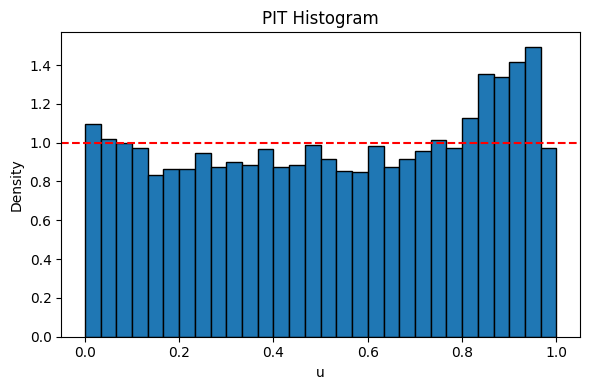

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pit, bins=30, density=True, edgecolor="k")
plt.axhline(1.0, color="red", linestyle="--")
plt.title("PIT Histogram")
plt.xlabel("u")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

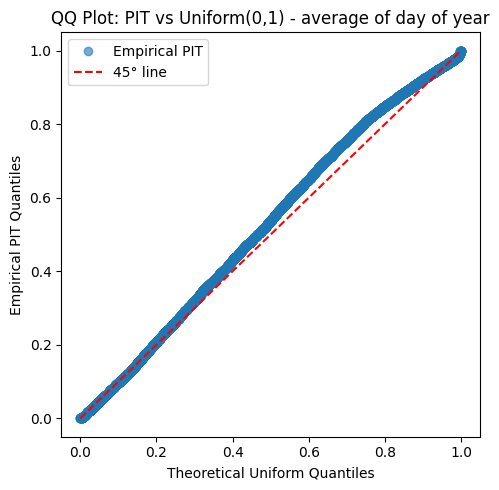

In [55]:
import numpy as np

pit_sorted = np.sort(pit)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1) - average of day of year")
plt.legend()
plt.tight_layout()
plt.show()

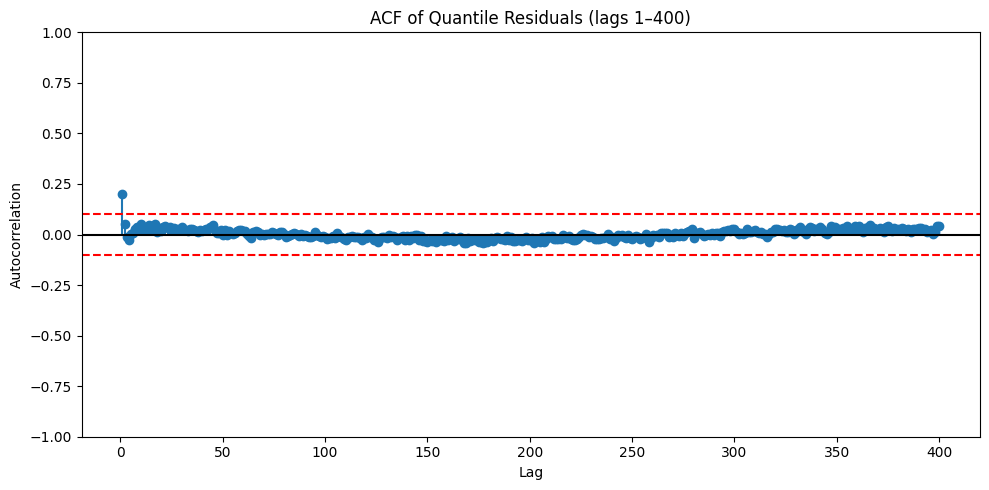

In [56]:
from statsmodels.tsa.stattools import acf

nlags = 400
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]   # drop lag 0
lags = np.arange(1, nlags+1)
conf = 0.1

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(conf, color="red", linestyle="--")
plt.axhline(-conf, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1.0, 1.0))
plt.tight_layout()
plt.show()

## ALL in

HS

In [2]:
import numpy as np
from scipy.special import expit
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution


def iterate_zagb2(
    # φ dynamics
    mu0_phi,
    gamma0_phi,
    alpha_phi,
    kappa_phi,
    kappas_tvp,
    c_phi,
    kappa_gamma_phi,

    # GB2 shape (initial values)
    gamma_init,
    xi_init,
    zeta_init,

    period,
    y,
    months,
    time_varying_parameters,
    mode="loglik"
):
    """
    Zero-Augmented GB2 with:
    - GAS φ_t
    - Persistent ARX logit π_t
    - Optional TVP for (gamma, xi, zeta)
    """

    gb2 = GB2LogLinkDistribution()

    T = len(y)
    K = len(omega_y)
    if T <= K:
        raise ValueError("Need T > number of lags K")

    n_eff = T - K

    # ---------- Allocate ----------
    mu_phi = np.zeros(n_eff + 1)
    gamma_phi = np.zeros((n_eff + 1, period))
    kappa_gamma_curr = np.zeros((n_eff + 1, period))
    phi = np.zeros(n_eff)

    gamma = np.zeros(n_eff)
    xi = np.zeros(n_eff)
    zeta = np.zeros(n_eff)

    score_phi = np.zeros(n_eff)
    score_gamma = np.zeros(n_eff)
    score_xi = np.zeros(n_eff)
    score_zeta = np.zeros(n_eff)

    # ---------- Initial states ----------
    mu_phi[0] = mu0_phi
    gamma[0] = gamma_init
    xi[0] = xi_init
    zeta[0] = zeta_init

    gamma_phi[0, :] = gamma0_phi.copy()

    loglik = 0.0

    # ---------- Main loop ----------
    for i, t in enumerate(range(K, T)):

        # ===== 1. Update TVP parameters FIRST =====
        if i > 0:
            gamma[i] = gamma[i-1]
            xi[i] = xi[i-1]
            zeta[i] = zeta[i-1]

            if 2 in time_varying_parameters:
                gamma[i] += kappas_tvp[1] * score_gamma[i-1]
            if 3 in time_varying_parameters:
                xi[i] += kappas_tvp[2] * score_xi[i-1]
            if 4 in time_varying_parameters:
                zeta[i] += kappas_tvp[3] * score_zeta[i-1]

        # validity
        if np.exp(zeta[i]) <= np.exp(gamma[i]):
            return 1e12

        # ===== 2. φ dynamics =====
        phi[i] = mu_phi[i] + gamma_phi[i, int(months[t] - 1)]


        if not np.isfinite(phi[i]):
            return 1e12

        # ===== 4. Likelihood =====
        if mode == "loglik":
            ll = gb2.logpdf(
                y[t],
                phi=phi[i],
                gamma=gamma[i],
                xi=xi[i],
                zeta=zeta[i],
            )
            loglik += ll

            if not np.isfinite(ll):
                return 1e12

        # ===== 5. Scores =====
        if y[t] > 0:
            scores = gb2.score(
                y[t],
                phi=phi[i],
                gamma=gamma[i],
                xi=xi[i],
                zeta=zeta[i],
            )
            score_phi[i], score_gamma[i], score_xi[i], score_zeta[i] = scores
        else:
            score_phi[i] = 0.0
            score_gamma[i] = 0.0
            score_xi[i] = 0.0
            score_zeta[i] = 0.0

        # ===== 6. GAS update for φ =====
        mu_phi[i+1] = c_phi + alpha_phi * mu_phi[i] + kappa_phi * score_phi[i]

        # ===== 7. Seasonal φ =====
        
        kappa_gamma_curr[i, :] = [kappa_gamma_phi if j==(months[t] - 1) else -kappa_gamma_phi/(period - 1) for j in range(period)]
        gamma_phi[i+1, :] = gamma_phi[i] + [score_phi[i]*kappa_gamma_curr[i, j] for j in range(period)]

    # ---------- Output ----------
    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "gamma": gamma,
            "xi": xi,
            "zeta": zeta,
            "mu_phi": mu_phi[:-1],
            "score_phi": score_phi,
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [3]:
def iterate_zagb2(
    mu0_phi,
    gamma0_phi,
    alpha_phi,
    kappa_phi,
    c_phi,
    kappa_gamma_phi,
    gamma_init,
    xi_init,
    zeta_init,
    period,
    y,
    months,
    mode="loglik"
):

    gb2 = GB2LogLinkDistribution()
    T = len(y)

    # Allocate
    phi = np.zeros(T + 1)
    gamma_phi = np.zeros((T + 1, period))

    gamma = np.zeros(T)
    xi = np.zeros(T)
    zeta = np.zeros(T)

    phi[0] = mu0_phi + gamma0_phi[int(months[0] - 1)]
    gamma_phi[0, :] = gamma0_phi.copy()

    gamma[0] = gamma_init
    xi[0] = xi_init
    zeta[0] = zeta_init

    loglik = 0.0

    for t in range(T):

        m = int(months[t] - 1)

        # Current phi consistent with seasonal
        phi[t] = phi[t]  # already set from previous step

        if not np.isfinite(phi[t]):
            return 1e12

        # Likelihood
        if mode == "loglik":
            ll = gb2.logpdf(
                y[t],
                phi=phi[t],
                gamma=gamma[t],
                xi=xi[t],
                zeta=zeta[t],
            )
            if not np.isfinite(ll):
                return 1e12
            loglik += ll

        # Score
        s = gb2.score(
            y[t],
            phi=phi[t],
            gamma=gamma[t],
            xi=xi[t],
            zeta=zeta[t],
        )

        score_phi = s[0]

        # Analytic Fisher (diagonal)
        I_t = gb2.fisher_information(
            y[t],
            phi=phi[t],
            gamma=gamma[t],
            xi=xi[t],
            zeta=zeta[t],
        )

        I_phi = I_t[0, 0]

        # Square-root scaling
        scaled_score = score_phi

        # =================================================
        # DIRECT AR(1) UPDATE ON φ
        # =================================================
        phi_next = (
            c_phi
            + alpha_phi * phi[t]
            + kappa_phi * scaled_score
        )

        # =================================================
        # Harrison–Stevens seasonal update
        # =================================================
        H = np.full(period, -1.0 / (period - 1))
        H[m] = 1.0

        gamma_phi[t+1, :] = (
            gamma_phi[t, :]
            + kappa_gamma_phi * scaled_score * H
        )

        # Reconstruct next φ consistently
        if t + 1 < T:
            phi[t+1] = phi_next  # AR part already includes persistence

            gamma[t+1] = gamma[t]
            xi[t+1] = xi[t]
            zeta[t+1] = zeta[t]

    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi[:-1],
            "gamma_phi": gamma_phi[:-1],
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [4]:
def objective_zagb2(theta, y, months, period=12):

    idx = 0

    # φ dynamics
    mu0_phi        = theta[idx]; idx += 1
    c_phi          = theta[idx]; idx += 1
    alpha1_phi      = theta[idx]; idx += 1
    kappa_phi      = theta[idx]; idx += 1
    kappa_gamma_phi = theta[idx]; idx += 1

    # GB2 shape
    gamma = theta[idx]; idx += 1
    xi    = theta[idx]; idx += 1
    zeta  = theta[idx]; idx += 1

    # φ seasonality
    gamma_phi = theta[idx:idx+period]; idx += period

    return iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma_phi,
        alpha_phi=alpha1_phi,
        kappa_phi=kappa_phi,
        kappa_gamma_phi=kappa_gamma_phi,
        c_phi=c_phi,

        gamma_init=gamma,
        xi_init=xi,
        zeta_init=zeta,
        period=period,
        y=y,
        months=months,
        mode="loglik"
    )


In [21]:
initials = initials.x

In [24]:
df

,Unnamed: 0,Data Medicao,"PRECIPITACAO TOTAL, DIARIO(mm)",Unnamed: 2,year,precipitation original,precipitation log,location,smoothed,smoothed log,month,year-month
0,0,01/01/2000,13.3,NaN,2000,13.3,258.851.563.240.702,BELO HORIZONTE,11.602398,"1,172473946",1,2000-01
1,1,02/01/2000,44.0,NaN,2000,44.0,3.784.416.880.823,BELO HORIZONTE,10.641599,"1,022796287",1,2000-01
2,2,03/01/2000,19.8,NaN,2000,19.8,298.618.686.071.046,BELO HORIZONTE,9.694234,"0,638453968",1,2000-01
3,3,04/01/2000,16.0,NaN,2000,16.0,27.732.135.270.086.200,BELO HORIZONTE,8.788815,"0,05472402",1,2000-01
4,4,05/01/2000,1.6,NaN,2000,1.6,0.4762341789963717,BELO HORIZONTE,7.949702,"-0,759276628",1,2000-01
...,...,...,...,...,...,...,...,...,...,...,...,...
8761,8761,27/12/2023,10.8,NaN,2023,10.8,23.804.716.316.511.100,BELO HORIZONTE,13.035376,"0,121374754",12,2023-12
8762,8762,28/12/2023,20.6,NaN,2023,20.6,30.257.763.949.023.600,BELO HORIZONTE,13.297024,"0,135670549",12,2023-12
8763,8763,29/12/2023,0.0,NaN,2023,0.0,-4.605.170.185.988.090,BELO HORIZONTE,13.509020,"-0,096797032",12,2023-12
8764,8764,30/12/2023,0.0,NaN,2023,0.0,-4.605.170.185.988.090,BELO HORIZONTE,13.672864,"0,048168719",12,2023-12


In [25]:
from scipy.optimize import minimize

INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab monthly"

harmonics = 6
period = 12

aics = {}
results = {}

for i,file in enumerate(os.listdir(INPUT)):
    
    loc = file.split("_")[-2]
     
    if file.split("_")[-1] == "train.csv" and i <= 2:
        
        print("Working on " + loc)
        
        aics[loc] = []
        results[loc] = []
        
        df = pd.read_csv(os.path.join(INPUT, file), sep=",")
        df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).values
        df['PRECIPITACAO TOTAL, DIARIO(mm)'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].fillna(df['smoothed']).str.replace(",", ".").astype(float)
        
        y = df.groupby('year-month')['PRECIPITACAO TOTAL, DIARIO(mm)'].sum().values
        months = df.groupby('year-month')['month'].mean().values
        
        y[y == 0] += 1.0
        
        for tvp in [[]]:
            
            print("Model = " + str([1] + tvp))
            
            theta0 = np.concatenate([
                np.array([
                    np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
                    np.log(y[1]) - np.log(y[0]),        # c_phi
                    0.01,       # alpha1_phi
                    0.01,       # alpha12_phi
                    0.01,       # kappa_phi
                    0.01,       # kappa gamma phi

                    initials[1],        # gamma
                    initials[2],        # xi
                    initials[3]         # zeta
                ]),
                np.zeros(period),        # gamma0_phi
            ])
        
            bounds = [
                    (np.log(np.mean(y[y > 0]) + 1e-3) - 4.0, np.log(np.mean(y[y > 0]) + 1e-3) + 5.0),     # mu0_phi
                    (0.0, 5.0),      # c_phi
                    (0.00, 0.995),   # alpha1_phi
                    (0.00, 0.995),   # alpha12_phi
                    (1e-4, 0.1),     # kappa_phi
                    (1e-4, 0.1),     # kappa gamma phi

                    (0.5, 2.5),      # gamma
                    (0.5, 3.0),      # xi
                    (2.5, 6.0)       # zeta

                ] + [(-5.0, 5.0)] * period
            res = minimize(
                objective_zagb2,
                theta0,
                args=(y, months, period),
                method="L-BFGS-B",
                bounds=bounds,
                options={
                    "disp": True,
                    "maxiter": 500,
                    "gtol": 1e-3,
                    "ftol": 1e-3
                }
            )
            
            results[loc].append(res)
            aics[loc].append(AIC_zagb2(res.x, y, months, period=12))

Working on BELO HORIZONTE
Model = [1]


C:\Users\ilang\AppData\Local\Temp\ipykernel_36520\3267007749.py:64: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


NameError: name 'AIC_zagb2' is not defined

In [26]:
idx = 0
K = 0

mu0_phi = res.x[idx]; idx+=1
c_phi = res.x[idx]; idx+=1
alpha1_phi = res.x[idx]; idx+=1
kappa_phi = res.x[idx]; idx+=1
kappa_gamma_phi = res.x[idx]; idx+=1

gamma_init = res.x[idx]; idx+=1
xi_init = res.x[idx]; idx+=1
zeta_init = res.x[idx]; idx+=1

gamma0_phi = res.x[idx:idx+period]; idx+=period

In [28]:
out = iterate_zagb2(
    mu0_phi=mu0_phi,
    gamma0_phi=gamma0_phi,
    alpha_phi=alpha1_phi,
    kappa_phi=kappa_phi,
    kappa_gamma_phi=kappa_gamma_phi,
    c_phi=c_phi,
    gamma_init=gamma_init,
    xi_init=xi_init,
    zeta_init=zeta_init,

    months=months,
    period=period,
    y=y,
    mode="filter"
)


In [6]:
import numpy as np
from scipy.special import betainc

def gb2_cdf(y, phi, gamma, xi, zeta):
    """
    CDF of GB2 distribution consistent with GB2LogLinkDistribution
    
    Parameters
    ----------
    y : float or array
        Observation(s), y > 0
    phi : float
        Log-scale parameter (sigma = exp(phi))
    gamma : float
        Shape parameter via p = exp(-gamma)
    xi : float
        Shape parameter via a = exp(xi)
    zeta : float
        Shape parameter via b = exp(zeta)
    """
    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    z = (y / sigma) ** p
    u = z / (1.0 + z)

    return betainc(a, b, u)


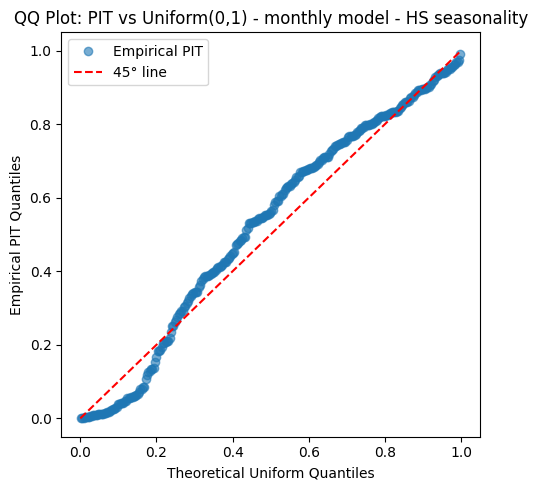

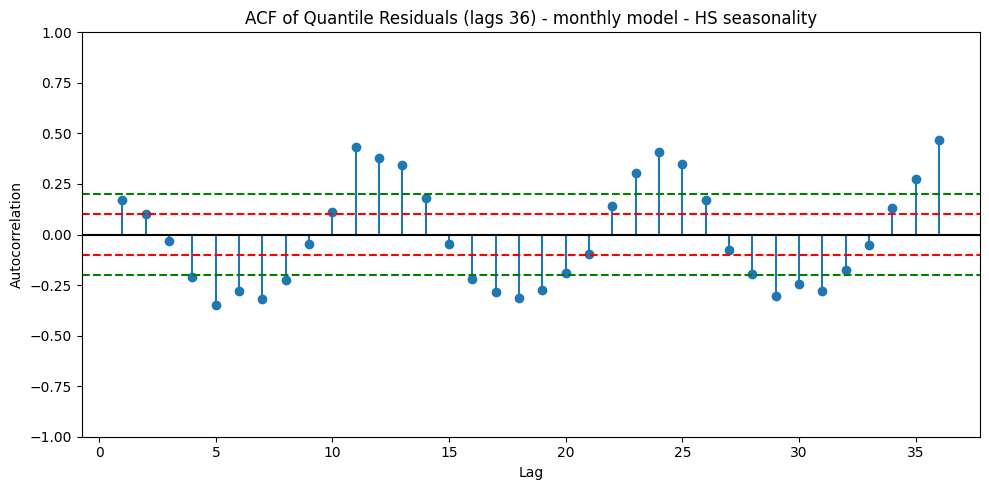

In [33]:
phi_hat = out["phi"]
gamma_hat = gamma_init
xi_hat = xi_init
zeta_hat = zeta_init

y_eff = y

pit = np.zeros(len(y_eff))
rng = np.random.default_rng(123)

for t in range(len(y_eff)):

    F = gb2_cdf(
        y_eff[t],
        phi_hat[t],
        gamma_hat,
        xi_hat,
        zeta_hat
    )
    pit[t] = F
    

import numpy as np
import matplotlib.pyplot as plt

pit_sorted = np.sort(pit)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1) - monthly model - HS seasonality")
plt.legend()
plt.tight_layout()
plt.show()

from scipy.stats import norm

qr = norm.ppf(pit)
qr = qr[np.isfinite(qr)]  # safety


from statsmodels.tsa.stattools import acf

nlags = 36
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]   # drop lag 0
lags = np.arange(1, nlags+1)
conf = 0.1
conf02 = 0.2

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(conf, color="red", linestyle="--")
plt.axhline(-conf, color="red", linestyle="--")

plt.axhline(conf02, color="green", linestyle="--")
plt.axhline(-conf02, color="green", linestyle="--")

plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 36) - monthly model - HS seasonality")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1.0, 1.0))
plt.tight_layout()
plt.show()

Try

In [91]:
def iterate_zagb2(
    mu0_phi,
    gamma_phi,          # cosine coefficients (static)
    gamma_star_phi,     # sine coefficients (static)
    alpha1_phi,         # AR(1)
    alpha12_phi,        # seasonal AR(12)
    kappa_phi,
    kappas_tvp,
    c_phi,
    gamma_init,
    xi_init,
    zeta_init,
    harmonics,
    period,
    time_varying_parameters,
    y,
    mode="loglik"
):

    gb2 = GB2LogLinkDistribution()
    T = len(y)

    # ------------------------------------------------
    # Allocate
    # ------------------------------------------------
    mu_phi = np.zeros(T + 1)
    phi = np.zeros(T)

    gamma = np.zeros(T)
    xi = np.zeros(T)
    zeta = np.zeros(T)

    score_phi = np.zeros(T)

    # ------------------------------------------------
    # Initial states
    # ------------------------------------------------
    mu_phi[0] = mu0_phi

    gamma[0] = gamma_init
    xi[0] = xi_init
    zeta[0] = zeta_init

    loglik = 0.0

    # ------------------------------------------------
    # Main loop
    # ------------------------------------------------
    for t in range(T):

        # ---------------------------
        # Deterministic harmonics
        # ---------------------------
        seasonal = 0.0
        for j in range(harmonics):
            lam = 2 * np.pi * (j + 1) / period
            seasonal += (
                gamma_phi[j] * np.cos(lam * t)
                + gamma_star_phi[j] * np.sin(lam * t)
            )

        phi[t] = mu_phi[t] + seasonal

        if not np.isfinite(phi[t]):
            return 1e12

        # ---------------------------
        # Likelihood
        # ---------------------------
        if mode == "loglik":
            ll = gb2.logpdf(
                y[t],
                phi=phi[t],
                gamma=gamma[t],
                xi=xi[t],
                zeta=zeta[t],
            )
            if not np.isfinite(ll):
                return 1e12
            loglik += ll

        # ---------------------------
        # Score
        # ---------------------------
        s = gb2.score(
            y[t],
            phi=phi[t],
            gamma=gamma[t],
            xi=xi[t],
            zeta=zeta[t],
        )

        score_phi[t] = s[0]

        scaled_score = score_phi[t]

        # ---------------------------
        # GAS update with AR(1) + AR(12)
        # ---------------------------
        if t + 1 < T:

            # AR(1)
            ar1 = alpha1_phi * mu_phi[t]

            # Seasonal AR
            if t >= period:
                ar12 = alpha12_phi * mu_phi[t + 1 - period]
            else:
                ar12 = 0.0

            mu_phi[t+1] = (
                c_phi
                + ar1
                + ar12
                + kappa_phi * scaled_score
            )

            # Carry forward static shape parameters
            
            if 2 in time_varying_parameters:
                gamma[t+1] = gamma[t] + kappas_tvp[1] * s[1]
            else:
                gamma[t+1] = gamma[t]
                
            if 3 in time_varying_parameters:
                xi[t+1] = xi[t] + kappas_tvp[2] * s[2]
            else:
                xi[t+1] = xi[t]
            
            if 4 in time_varying_parameters:
                zeta[t+1] = zeta[t] + kappas_tvp[3] * s[3]
            else:
                zeta[t+1] = zeta[t]

    # ------------------------------------------------
    # Output
    # ------------------------------------------------
    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "gamma": gamma,
            "xi": xi,
            "zeta": zeta,
            "mu_phi": mu_phi[:-1]
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [92]:
# import numpy as np
# from scipy.special import expit
# from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution


# def iterate_zagb2(
#     # φ dynamics
#     mu0_phi,
#     gamma0_phi,
#     gamma_star0_phi,
#     alpha_phi,
#     kappa_phi,
#     kappas_tvp,
#     c_phi,
#     kappa_gamma_phi,

#     # GB2 shape (initial values)
#     gamma_init,
#     xi_init,
#     zeta_init,

#     harmonics,
#     period,
#     y,
#     time_varying_parameters,
#     mode="loglik"
# ):
#     """
#     Zero-Augmented GB2 with:
#     - GAS φ_t
#     - Persistent ARX logit π_t
#     - Optional TVP for (gamma, xi, zeta)
#     """

#     gb2 = GB2LogLinkDistribution()

#     T = len(y)
#     K = 0
#     if T <= K:
#         raise ValueError("Need T > number of lags K")

#     n_eff = T - K

#     # ---------- Allocate ----------
#     mu_phi = np.zeros(n_eff + 1)
#     phi = np.zeros(n_eff)

#     gamma = np.zeros(n_eff)
#     xi = np.zeros(n_eff)
#     zeta = np.zeros(n_eff)

#     score_phi = np.zeros(n_eff)
#     score_gamma = np.zeros(n_eff)
#     score_xi = np.zeros(n_eff)
#     score_zeta = np.zeros(n_eff)

#     # ---------- Initial states ----------
#     mu_phi[0] = mu0_phi
#     gamma[0] = gamma_init
#     xi[0] = xi_init
#     zeta[0] = zeta_init

#     gamma_phi = gamma0_phi.copy()
#     gamma_star_phi = gamma_star0_phi.copy()

#     loglik = 0.0

#     # ---------- Main loop ----------
#     for i, t in enumerate(range(K, T)):

#         # ===== 1. Update TVP parameters FIRST =====
#         if i > 0:
#             gamma[i] = gamma[i-1]
#             xi[i] = xi[i-1]
#             zeta[i] = zeta[i-1]

#             if 2 in time_varying_parameters:
#                 gamma[i] += kappas_tvp[1] * score_gamma[i-1]
#             if 3 in time_varying_parameters:
#                 xi[i] += kappas_tvp[2] * score_xi[i-1]
#             if 4 in time_varying_parameters:
#                 zeta[i] += kappas_tvp[3] * score_zeta[i-1]

#         # validity
#         if np.exp(zeta[i]) <= np.exp(gamma[i]):
#             return 1e12

#         # ===== 2. φ dynamics =====
#         phi[i] = mu_phi[i] + np.sum(gamma_phi)

#         if not np.isfinite(phi[i]):
#             return 1e12

#         # ===== 4. Likelihood =====
#         if mode == "loglik":
#             ll = gb2.logpdf(
#                 y[t],
#                 phi=phi[i],
#                 gamma=gamma[i],
#                 xi=xi[i],
#                 zeta=zeta[i],
#             )

#             if not np.isfinite(ll):
#                 return 1e12

#             loglik += ll

#         # ===== 5. Scores =====
#         if y[t] > 0:
#             scores = gb2.score(
#                 y[t],
#                 phi=phi[i],
#                 gamma=gamma[i],
#                 xi=xi[i],
#                 zeta=zeta[i]
#             )
#             fisher = gb2.fisher_information(
#                 y[t],
#                 phi=phi[i],
#                 gamma=gamma[i],
#                 xi=xi[i],
#                 zeta=zeta[i]
#             )
#             inverted_fisher = np.linalg.inv(fisher)
#             score_phi[i], score_gamma[i], score_xi[i], score_zeta[i] = scores
#         else:
#             score_phi[i] = 0.0
#             score_gamma[i] = 0.0
#             score_xi[i] = 0.0
#             score_zeta[i] = 0.0

#         # ===== 6. GAS update for φ =====
#         mu_phi[i+1] = c_phi + alpha_phi * mu_phi[i] + kappa_phi * score_phi[i]

#         # ===== 7. Seasonal φ =====
#         for j in range(harmonics):
#             lam = 2 * np.pi * (j + 1) / period
#             g = gamma_phi[j]
#             gs = gamma_star_phi[j]

#             gamma_phi[j] = np.cos(lam) * g + np.sin(lam) * gs + kappa_gamma_phi * score_phi[i]
#             gamma_star_phi[j] = np.cos(lam) * gs - np.sin(lam) * g + kappa_gamma_phi * score_phi[i]

#     # ---------- Output ----------
#     if mode == "loglik":
#         return -loglik

#     elif mode == "filter":
#         return {
#             "phi": phi,
#             "gamma": gamma,
#             "xi": xi,
#             "zeta": zeta,
#             "mu_phi": mu_phi[:-1],
#             "score_phi": score_phi,
#         }

#     else:
#         raise ValueError("mode must be 'loglik' or 'filter'")


In [93]:
# def iterate_zagb2(
#     mu0_phi,
#     gamma0_phi,        # seasonal initial vector (size = period)
#     alpha1_phi,
#     alpha12_phi,
#     kappa_phi,
#     kappa_gamma_phi,
#     c_phi,
#     gamma_init,
#     xi_init,
#     zeta_init,
#     period,
#     months,
#     y,
#     mode="loglik"
# ):

#     gb2 = GB2LogLinkDistribution()
#     T = len(y)

#     # ----------------------------------
#     # Allocate
#     # ----------------------------------
#     mu_phi = np.zeros(T + 1)
#     gamma_phi = np.zeros((T + 1, period))
#     phi = np.zeros(T)

#     gamma = np.zeros(T)
#     xi = np.zeros(T)
#     zeta = np.zeros(T)

#     # ----------------------------------
#     # Initial states
#     # ----------------------------------
#     mu_phi[0] = mu0_phi
#     gamma_phi[0, :] = gamma0_phi.copy()

#     gamma[0] = gamma_init
#     xi[0] = xi_init
#     zeta[0] = zeta_init

#     loglik = 0.0

#     # ----------------------------------
#     # Main loop
#     # ----------------------------------
#     for t in range(T):

#         m = int(months[t] - 1)

#         # Construct phi
#         phi[t] = mu_phi[t] + gamma_phi[t, m]

#         if not np.isfinite(phi[t]):
#             return 1e12

#         # Likelihood
#         if mode == "loglik":
#             ll = gb2.logpdf(
#                 y[t],
#                 phi=phi[t],
#                 gamma=gamma[t],
#                 xi=xi[t],
#                 zeta=zeta[t],
#             )
#             if not np.isfinite(ll):
#                 return 1e12
#             loglik += ll

#         # Score
#         s = gb2.score(
#             y[t],
#             phi=phi[t],
#             gamma=gamma[t],
#             xi=xi[t],
#             zeta=zeta[t],
#         )

#         score_phi = s[0]

#         # Fisher scaling
#         fisher = gb2.fisher_information(
#             y[t],
#             phi=phi[t],
#             gamma=gamma[t],
#             xi=xi[t],
#             zeta=zeta[t],
#         )

#         I_phi = fisher[0, 0]
#         scaled_score = score_phi

#         # ----------------------------------
#         # LEVEL UPDATE (AR1 + AR12)
#         # ----------------------------------
#         if t + 1 < T:

#             ar1 = alpha1_phi * mu_phi[t]

#             if t >= period:
#                 ar12 = alpha12_phi * mu_phi[t - period]
#             else:
#                 ar12 = 0.0

#             mu_phi[t+1] = (
#                 c_phi
#                 + ar1
#                 + ar12
#                 + kappa_phi * scaled_score
#             )

#             # ----------------------------------
#             # Harrison–Stevens seasonal update
#             # ----------------------------------

#             H = np.full(period, -1.0 / (period - 1))
            
#             H[m] = 1.0

#             gamma_phi[t+1, :] = (
#                 gamma_phi[t, :]
#                 + kappa_gamma_phi * scaled_score * H
#             )

#             # Carry forward static shape parameters
#             gamma[t+1] = gamma[t]
#             xi[t+1] = xi[t]
#             zeta[t+1] = zeta[t]

#     # ----------------------------------
#     # Output
#     # ----------------------------------
#     if mode == "loglik":
#         return -loglik

#     elif mode == "filter":
#         return {
#             "phi": phi,
            
#             "mu_phi": mu_phi[:-1],
#             "gamma_phi": gamma_phi[:-1],
#         }

#     else:
#         raise ValueError("mode must be 'loglik' or 'filter'")


End try

In [94]:
def objective_zagb2(theta, y, tvp, harmonics, period=12):

    idx = 0
    
    kappas_tvp = np.zeros(4)

    # φ dynamics
    mu0_phi        = theta[idx]; idx += 1
    c_phi          = theta[idx]; idx += 1
    alpha1_phi      = theta[idx]; idx += 1
    alpha12_phi      = theta[idx]; idx += 1
    kappa_phi      = theta[idx]; idx += 1
    
    for i,_ in enumerate(kappas_tvp):
        if i+1 in tvp:
            kappas_tvp[i] = theta[idx]; idx += 1
    
    # if len(tvp) > 0:
    #     for i, v in enumerate(tvp): 
    #         kappas_tvp[v-1] = theta[idx]; idx += 1

    # GB2 shape
    gamma = theta[idx]; idx += 1
    xi    = theta[idx]; idx += 1
    zeta  = theta[idx]; idx += 1

    # φ seasonality
    gamma0_phi = theta[idx:idx+harmonics]; idx += harmonics
    gamma0_star_phi = theta[idx:idx+harmonics]; idx += harmonics

    return iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma_phi=gamma0_phi,
        gamma_star_phi=gamma0_star_phi,
        alpha1_phi=alpha1_phi,
        alpha12_phi=alpha12_phi,
        kappa_phi=kappa_phi,
        kappas_tvp=kappas_tvp,
        c_phi=c_phi,
        # kappa_gamma_phi=kappa_gamma_phi,

        gamma_init=gamma,
        xi_init=xi,
        zeta_init=zeta,

        period=period,
        y=y,
        harmonics=harmonics,
        time_varying_parameters=tvp,
        mode="loglik"
    )


In [ ]:
def AIC_zagb2(theta, y, tvp, harmonics=6, period=12):

    idx = 0
    
    kappas_tvp = np.zeros(4)

    # φ dynamics
    mu0_phi        = theta[idx]; idx += 1
    c_phi          = theta[idx]; idx += 1
    alpha1_phi      = theta[idx]; idx += 1
    alpha12_phi      = theta[idx]; idx += 1
    kappa_phi      = theta[idx]; idx += 1
    
    for i,_ in enumerate(kappas_tvp):
        if i+1 in tvp:
            kappas_tvp[i] = theta[idx]; idx += 1
    
    # if len(tvp) > 0:
    #     for i, v in enumerate(tvp): 
    #         kappas_tvp[v-1] = theta[idx]; idx += 1
    

    # GB2 shape
    gamma = theta[idx]; idx += 1
    xi    = theta[idx]; idx += 1
    zeta  = theta[idx]; idx += 1

    # φ seasonality
    gamma0_phi = theta[idx:idx+harmonics]; idx += harmonics
    gamma0_star_phi = theta[idx:idx+harmonics]; idx += harmonics

    loglik = -iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma_phi=gamma0_phi,
        gamma_star_phi=gamma0_star_phi,
        alpha1_phi=alpha1_phi,
        alpha12_phi=alpha12_phi,
        kappa_phi=kappa_phi,
        kappas_tvp=kappas_tvp,
        c_phi=c_phi,
        # kappa_gamma_phi=kappa_gamma_phi,

        gamma_init=gamma,
        xi_init=xi,
        zeta_init=zeta,

        period=period,
        y=y,
        harmonics=harmonics,
        time_varying_parameters=tvp,
        mode="loglik"
    )
    
    return 2 * (len(theta) - loglik)


Init

In [15]:
import pandas as pd
import os

INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab monthly"
df = pd.read_csv(os.path.join(INPUT, os.listdir(INPUT)[1]), sep=";")
df['month-year'] = pd.to_datetime(df['Data Medicao'], format = '%d/%m/%Y').dt.strftime("%Y-%m")
df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).values
df['PRECIPITACAO TOTAL, DIARIO(mm)'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].fillna(df['smoothed']).str.replace(",", ".").astype(float)
y = df.groupby('month-year')['PRECIPITACAO TOTAL, DIARIO(mm)'].sum().values
y[y == 0] += 1.0

In [16]:
def independent(args, y):
    gb2 = GB2LogLinkDistribution()
    
    args = {
        "phi": args[0],
        "gamma": args[1],
        "xi": args[2],
        "zeta": args[3]
    }
    
    sum = 0
    for obs in y:
        sum += gb2.logpdf(obs, 
                          phi=args['phi'],
                          gamma=args['gamma'],
                          xi=args['xi'],
                          zeta=args['zeta'])
    return -sum

In [17]:
from scipy.optimize import minimize

bounds = [
        (-5.0, 5.0),     # phi
        (0.5, 2.5),      # gamma
        (0.5, 3.0),      # xi
        (2.5, 6.0)       # zeta
]

theta0 = [0.5, 1.2, 1.2, 5.0]

initials = minimize(
    independent,
    theta0,
    args=(y),
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "disp": True,
        "maxiter": 500,
        "gtol": 1e-3,
        "ftol": 1e-3
    }
)

C:\Users\ilang\AppData\Local\Temp\ipykernel_7444\2050857555.py:12: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  initials = minimize(


In [19]:
initials

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 1689.0723700327082
        x: [ 4.493e+00  1.627e+00  2.532e+00  2.672e+00]
      nit: 9
      jac: [-1.329e+00  4.385e-01  1.136e+00 -6.294e-01]
     nfev: 50
     njev: 10
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

In [216]:
pd.DataFrame(y).to_csv("aea.csv", index=False)

In [320]:
df['month'] = pd.to_datetime(df['Data Medicao'], format = '%d/%m/%Y').dt.month
months = df.groupby('year-month')['month'].mean()

In [181]:
from scipy.optimize import minimize

INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab monthly"

harmonics = 6
period = 12

aics = {}
results = {}

for i,file in enumerate(os.listdir(INPUT)):
    
    loc = file.split("_")[-2]
     
    if file.split("_")[-1] == "train.csv":
        
        print("Working on " + loc)
        
        aics[loc] = []
        results[loc] = []
        
        df = pd.read_csv(os.path.join(INPUT, file), sep=";")
        df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).values
        df['PRECIPITACAO TOTAL, DIARIO(mm)'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].fillna(df['smoothed']).str.replace(",", ".").astype(float)
        
        y = df.groupby('year-month')['PRECIPITACAO TOTAL, DIARIO(mm)'].sum().values
        
        y[y == 0] += 1.0
        
        bounds = [
                (-5.0, 5.0),     # phi
                (0.5, 2.5),      # gamma
                (0.5, 3.0),      # xi
                (2.5, 6.0)       # zeta
        ]

        # theta0 = [0.5, 1.2, 1.2, 5.0]

        # initials = minimize(
        #     independent,
        #     theta0,
        #     args=(y),
        #     method="L-BFGS-B",
        #     bounds=bounds,
        #     options={
        #         "disp": True,
        #         "maxiter": 500,
        #         "gtol": 1e-3,
        #         "ftol": 1e-3
        #     }
        # )
        
        for tvp in [[], [3]]:
            
            print("Model = " + str([1] + tvp))
            
            if tvp == [3]:
            
                theta0 = np.concatenate([
                    np.array([
                        np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
                        np.log(y[1]) - np.log(y[0]),        # c_phi
                        0.01,       # alpha1_phi
                        0.01,       # alpha12_phi
                        0.01,       # kappa_phi
                        *[0.01],

                        1.2,
                        1.2,
                        5.0
                    ]),
                    np.zeros(harmonics),        # gamma0_phi
                    np.zeros(harmonics),        # gamma0_star_phi
                ])
            
                bounds = [
                        (np.log(np.mean(y[y > 0]) + 1e-3) - 4.0, np.log(np.mean(y[y > 0]) + 1e-3) + 5.0),     # mu0_phi
                        (0.0, 5.0),      # c_phi
                        (0.00, 0.995),   # alpha1_phi
                        (0.00, 0.995),   # alpha12_phi
                        (1e-4, 0.1),     # kappa_phi
                        *[(1e-4, 0.1)],     # kappa_xi

                        (0.5, 2.5),      # gamma
                        (0.5, 3.0),      # xi
                        (2.5, 6.0)       # zeta

                    ] + [(-5.0, 5.0)] * harmonics + [(-5.0, 5.0)] * harmonics
            
            else:
                
                theta0 = np.concatenate([
                    np.array([
                        np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
                        np.log(y[1]) - np.log(y[0]),        # c_phi
                        0.01,       # alpha1_phi
                        0.01,       # alpha12_phi
                        0.01,       # kappa_phi

                        initials.x[1],        # gamma
                        initials.x[2],        # xi
                        initials.x[3]         # zeta
                    ]),
                    np.zeros(harmonics),        # gamma0_phi
                    np.zeros(harmonics),        # gamma0_star_phi
                ])
            
                bounds = [
                        (np.log(np.mean(y[y > 0]) + 1e-3) - 4.0, np.log(np.mean(y[y > 0]) + 1e-3) + 5.0),     # mu0_phi
                        (0.0, 5.0),      # c_phi
                        (0.00, 0.995),   # alpha1_phi
                        (0.00, 0.995),   # alpha12_phi
                        (1e-4, 0.1),     # kappa_phi

                        (0.5, 2.5),      # gamma
                        (0.5, 3.0),      # xi
                        (2.5, 6.0)       # zeta

                    ] + [(-5.0, 5.0)] * harmonics + [(-5.0, 5.0)] * harmonics                
            res = minimize(
                objective_zagb2,
                theta0,
                args=(y, tvp, harmonics, period),
                method="L-BFGS-B",
                bounds=bounds,
                options={
                    "disp": True,
                    "maxiter": 500,
                    "gtol": 1e-3,
                    "ftol": 1e-3
                }
            )
            
            results[loc].append(res)
            aics[loc].append(AIC_zagb2(res.x, y, tvp, period=12))

Working on BELO HORIZONTE
Model = [1]


C:\Users\ilang\AppData\Local\Temp\ipykernel_7444\247860239.py:120: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:34: RuntimeWarning: overflow encountered in exp
  * np.log(1 + (y / np.exp(phi)) ** (np.exp(-gamma)))


Model = [1, 3]
Working on GARANHUNS (PERNAMBUCO)
Model = [1]


C:\Users\ilang\AppData\Local\Temp\ipykernel_7444\247860239.py:120: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:34: RuntimeWarning: overflow encountered in exp
  * np.log(1 + (y / np.exp(phi)) ** (np.exp(-gamma)))


Model = [1, 3]
Working on MACEIÓ
Model = [1]


...

Model = [1, 3]
Working on SALVADOR
Model = [1]


C:\Users\ilang\AppData\Local\Temp\ipykernel_7444\247860239.py:120: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:34: RuntimeWarning: overflow encountered in exp
  * np.log(1 + (y / np.exp(phi)) ** (np.exp(-gamma)))


Model = [1, 3]
Working on SÃO PAULO
Model = [1]


C:\Users\ilang\AppData\Local\Temp\ipykernel_7444\247860239.py:120: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:34: RuntimeWarning: overflow encountered in exp
  * np.log(1 + (y / np.exp(phi)) ** (np.exp(-gamma)))


Model = [1, 3]


In [190]:
os.listdir(INPUT)[3]

'GARANHUNS (PERNAMBUCO)_train.csv'

In [251]:
file = os.listdir(INPUT)[1]

df = pd.read_csv(os.path.join(INPUT, file), sep=";")
df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).values
df['PRECIPITACAO TOTAL, DIARIO(mm)'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].fillna(df['smoothed']).str.replace(",", ".").astype(float)

y = df.groupby('year-month')['PRECIPITACAO TOTAL, DIARIO(mm)'].sum().values

y[y == 0] += 1.0

In [142]:
results['SALVADOR'][0].x

array([ 4.99943905,  1.63808039,  0.58305309,  0.        ,  0.05681717,
        0.73865507,  2.90562232,  2.55654393, -0.54919999, -0.19777458,
       -0.04320805,  0.04027718,  0.03738271,  0.02769697,  0.48588355,
       -0.1975202 , -0.07931968,  0.07041951,  0.01224231,  0.        ])

In [252]:
res = results['BELO HORIZONTE'][0]
res

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 1515.8017815405522
        x: [ 4.994e+00  1.249e+00 ...  3.455e-02  0.000e+00]
      nit: 16
      jac: [ 1.934e+00  1.209e+00 ...  1.843e+00  0.000e+00]
     nfev: 483
     njev: 23
 hess_inv: <20x20 LbfgsInvHessProduct with dtype=float64>

In [253]:
idx = 0
K = 0

mu0_phi = res.x[idx]; idx+=1
c_phi = res.x[idx]; idx+=1
alpha1_phi = res.x[idx]; idx+=1
alpha12_phi = res.x[idx]; idx+=1
kappa_phi = res.x[idx]; idx+=1

gamma_init = res.x[idx]; idx+=1
xi_init = res.x[idx]; idx+=1
zeta_init = res.x[idx]; idx+=1

gamma0_phi = res.x[idx:idx+harmonics]; idx+=harmonics
gamma0_star_phi = res.x[idx:idx+harmonics]; idx+=harmonics


In [254]:
out = iterate_zagb2(
    mu0_phi=mu0_phi,
    gamma_phi=gamma0_phi,
    gamma_star_phi=gamma0_star_phi,
    alpha1_phi=alpha1_phi,
    alpha12_phi=alpha12_phi,
    kappa_phi=kappa_phi,
    kappas_tvp=[0,0,0,0],
    c_phi=c_phi,
    gamma_init=gamma_init,
    xi_init=xi_init,
    zeta_init=zeta_init,
    period=period,
    harmonics=6,
    time_varying_parameters=[],
    y=y,
    mode="filter"
)


In [255]:
phi_hat = out["phi"]
gamma_hat = out["gamma"]
xi_hat = out["xi"]
zeta_hat = zeta_init

y_eff = y

pit = np.zeros(len(y_eff))
rng = np.random.default_rng(123)

for t in range(len(y_eff)):

    F = gb2_cdf(
        y_eff[t],
        phi_hat[t],
        gamma_hat[t],
        xi_hat[t],
        zeta_hat
    )
    pit[t] = F


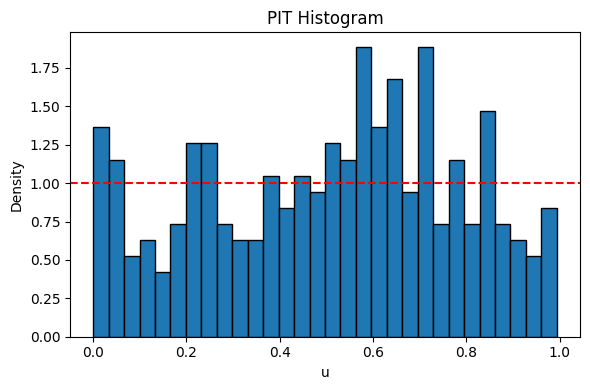

In [256]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pit, bins=30, density=True, edgecolor="k")
plt.axhline(1.0, color="red", linestyle="--")
plt.title("PIT Histogram")
plt.xlabel("u")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ilang\AppData\Local\Temp\ipykernel_7444\2574060717.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.title("QQ Plot: PIT vs Uniform(0,1) - deterministic seasonality with $\mu$ AR(1, 12)")


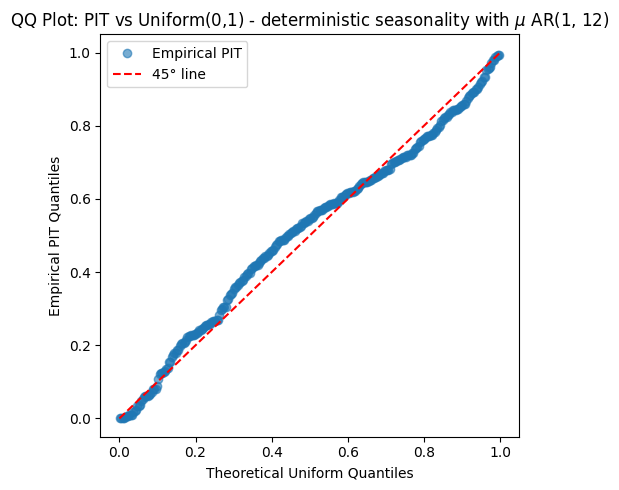

In [257]:
import numpy as np

pit_sorted = np.sort(pit)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1) - deterministic seasonality with $\mu$ AR(1, 12)")
plt.legend()
plt.tight_layout()
plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ilang\AppData\Local\Temp\ipykernel_7444\1129389364.py:26: SyntaxWarning: invalid escape sequence '\m'
  plt.title("ACF of Quantile Residuals (lags 1–400) - deterministic seasonality $\mu$ AR(1,12) - phi and xi time varying")


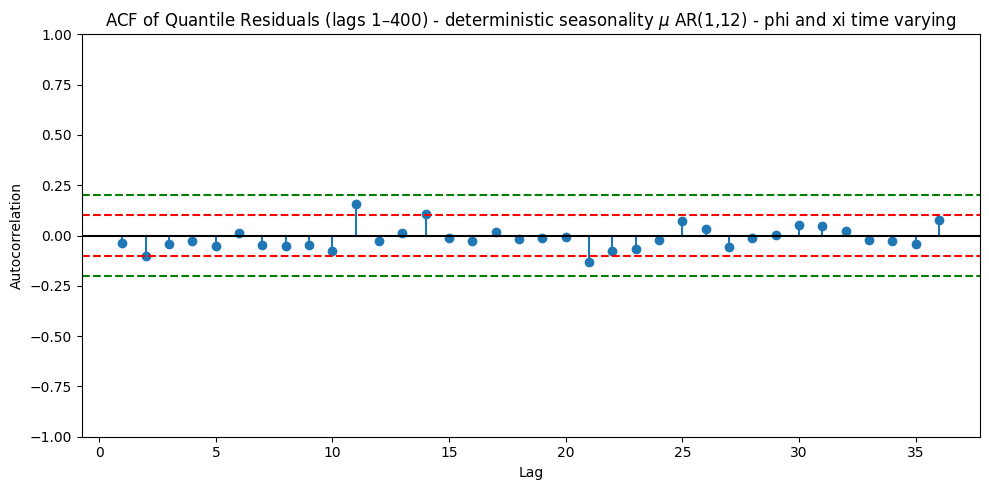

In [258]:
from scipy.stats import norm

qr = norm.ppf(pit)
qr = qr[np.isfinite(qr)]  # safety


from statsmodels.tsa.stattools import acf

nlags = 36
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]   # drop lag 0
lags = np.arange(1, nlags+1)
conf = 0.1
conf02 = 0.2

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(conf, color="red", linestyle="--")
plt.axhline(-conf, color="red", linestyle="--")

plt.axhline(conf02, color="green", linestyle="--")
plt.axhline(-conf02, color="green", linestyle="--")

plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400) - deterministic seasonality $\mu$ AR(1,12) - phi and xi time varying")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1.0, 1.0))
plt.tight_layout()
plt.show()

Try end

In [216]:
import pandas as pd
import numpy as np


# Create DataFrame
df_aics = pd.DataFrame(aics).transpose()
df_aics.columns = [
    "Model Phi time-varying",
    "Model Phi and Xi time-varying"
]


# Compute percentual difference
df_aics["Percent Difference (%)"] = (
    (df_aics.max(axis=1) - df_aics.min(axis=1))
    / df_aics.min(axis=1)
) * 100


# Formatting function
def format_row(row):
    min_mask = row.iloc[:2] == row.iloc[:2].min()  # only compare model columns
    
    formatted_values = []
    
    # Format model columns
    for value, is_min in zip(row.iloc[:2], min_mask):
        if is_min:
            formatted_values.append(f"\\textbf{{{value:.3f}}}")
        else:
            formatted_values.append(f"{value:.3f}")
    
    # Format percent column
    formatted_values.append(f"{row.iloc[2]:.2f}\\%")
    
    return pd.Series(formatted_values, index=row.index)


# Apply formatting
df_formatted = df_aics.apply(format_row, axis=1)


# Generate LaTeX
latex_table = df_formatted.to_latex(
    escape=False,
    column_format="lccc",
    caption="AIC comparison between competing models",
    label="tab:aic_comparison"
)

print(latex_table)

\begin{table}
\caption{AIC comparison between competing models}
\label{tab:aic_comparison}
\begin{tabular}{lccc}
\toprule
 & Model Phi time-varying & Model Phi and Xi time-varying & Percent Difference (%) \\
\midrule
BELO HORIZONTE & \textbf{3071.604} & 5124.898 & 66.85\% \\
GARANHUNS (PERNAMBUCO) & \textbf{2004.091} & 2748.800 & 37.16\% \\
MACEIÓ & \textbf{2266.492} & 2856.416 & 26.03\% \\
MANAUS & \textbf{3602.276} & 4967.581 & 37.90\% \\
SALVADOR & \textbf{3287.838} & 4947.208 & 50.47\% \\
SÃO PAULO & \textbf{3069.765} & 3689.222 & 20.18\% \\
\bottomrule
\end{tabular}
\end{table}



In [233]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def build_results_table(results, harmonics=6, K=3):

    latex_tables = {}

    for loc in results.keys():

        res = results[loc]  # assuming first model per location
        theta = res.x
        grad  = res.jac

        # Inverse Hessian
        try:
            H_inv = res.hess_inv.todense()
        except:
            H_inv = res.hess_inv

        se = np.sqrt(np.diag(H_inv))

        # t-stats and p-values (two-tailed normal approx)
        tvals = theta / se
        pvals = 2 * (1 - norm.cdf(np.abs(tvals)))

        # -------------------------------
        # Parameter names in correct order
        # -------------------------------
        names = []

        names += ["mu0\_phi"]
        names += ["c\_phi"]
        names += ["alpha\_1\_phi"]
        names += ["alpha\_12\_phi"]
        names += ["kappa\_phi"]

        names += ["gamma\_init"]
        names += ["xi\_init"]
        names += ["zeta\_init"]

        for h in range(harmonics):
            names += [f"gamma0\_phi\_{h+1}"]
            
        for h in range(harmonics):
            names += [f"gamma0\_star\_phi\_{h+1}"]
            

        # -------------------------------
        # Create dataframe
        # -------------------------------
        df = pd.DataFrame({
            "Parameter": names,
            "Estimate": theta,
            "Gradient": grad,
            "Std.Error": se,
            "t-value": tvals,
            "p-value": pvals
        })

        # Formatting
        df["Estimate"] = df["Estimate"].map(lambda x: f"{x:.6f}")
        df["Gradient"] = df["Gradient"].map(lambda x: f"{x:.3f}")
        df["Std.Error"] = df["Std.Error"].map(lambda x: f"{x:.6f}")
        df["t-value"] = df["t-value"].map(lambda x: f"{x:.3f}")
        df["p-value"] = df["p-value"].map(lambda x: f"{x:.4f}")

        # Convert to LaTeX
        latex_table = df.to_latex(
            index=False,
            escape=False,
            column_format="lccccc",
            caption=f"Parameter estimates for {loc}",
            label=f"tab:{loc.lower().replace(' ','_')}_results"
        )

        latex_tables[loc] = latex_table

    return latex_tables

<>:32: SyntaxWarning: invalid escape sequence '\_'
<>:33: SyntaxWarning: invalid escape sequence '\_'
<>:34: SyntaxWarning: invalid escape sequence '\_'
<>:35: SyntaxWarning: invalid escape sequence '\_'
<>:36: SyntaxWarning: invalid escape sequence '\_'
<>:38: SyntaxWarning: invalid escape sequence '\_'
<>:39: SyntaxWarning: invalid escape sequence '\_'
<>:40: SyntaxWarning: invalid escape sequence '\_'
<>:43: SyntaxWarning: invalid escape sequence '\_'
<>:46: SyntaxWarning: invalid escape sequence '\_'
<>:32: SyntaxWarning: invalid escape sequence '\_'
<>:33: SyntaxWarning: invalid escape sequence '\_'
<>:34: SyntaxWarning: invalid escape sequence '\_'
<>:35: SyntaxWarning: invalid escape sequence '\_'
<>:36: SyntaxWarning: invalid escape sequence '\_'
<>:38: SyntaxWarning: invalid escape sequence '\_'
<>:39: SyntaxWarning: invalid escape sequence '\_'
<>:40: SyntaxWarning: invalid escape sequence '\_'
<>:43: SyntaxWarning: invalid escape sequence '\_'
<>:46: SyntaxWarning: invalid e

In [234]:
results_final = {k: r[0] for k, r in results.items()}

In [235]:
latex_tables = build_results_table(results_final, harmonics=6, K=3)

for k in results.keys():
    print(latex_tables[k])

\begin{table}
\caption{Parameter estimates for BELO HORIZONTE}
\label{tab:belo_horizonte_results}
\begin{tabular}{lccccc}
\toprule
Parameter & Estimate & Gradient & Std.Error & t-value & p-value \\
\midrule
mu0\_phi & 4.994474 & 1.934 & 1.026903 & 4.864 & 0.0000 \\
c\_phi & 1.249093 & 1.209 & 2.880790 & 0.434 & 0.6646 \\
alpha\_1\_phi & 0.350981 & 7.443 & 1.087022 & 0.323 & 0.7468 \\
alpha\_12\_phi & 0.083814 & 3.934 & 0.858156 & 0.098 & 0.9222 \\
kappa\_phi & 0.099654 & 13.945 & 1.137519 & 0.088 & 0.9302 \\
gamma\_init & 1.104908 & 9.066 & 0.841954 & 1.312 & 0.1894 \\
xi\_init & 3.000000 & 11.372 & 0.880776 & 3.406 & 0.0007 \\
zeta\_init & 2.500000 & -14.555 & 0.972549 & 2.571 & 0.0102 \\
gamma0\_phi\_1 & 2.286588 & -3.039 & 1.113187 & 2.054 & 0.0400 \\
gamma0\_phi\_2 & -0.601099 & -0.603 & 1.002149 & -0.600 & 0.5486 \\
gamma0\_phi\_3 & 0.014244 & 1.121 & 0.994749 & 0.014 & 0.9886 \\
gamma0\_phi\_4 & 0.022897 & -0.165 & 1.001280 & 0.023 & 0.9818 \\
gamma0\_phi\_5 & 0.034090 & -0.327 &

In [28]:
import numpy as np
from scipy.special import betainc

def gb2_cdf(y, phi, gamma, xi, zeta):
    """
    CDF of GB2 distribution consistent with GB2LogLinkDistribution
    
    Parameters
    ----------
    y : float or array
        Observation(s), y > 0
    phi : float
        Log-scale parameter (sigma = exp(phi))
    gamma : float
        Shape parameter via p = exp(-gamma)
    xi : float
        Shape parameter via a = exp(xi)
    zeta : float
        Shape parameter via b = exp(zeta)
    """
    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    z = (y / sigma) ** p
    u = z / (1.0 + z)

    return betainc(a, b, u)


In [41]:
y

array([3.283e+02, 2.466e+02, 1.001e+02, 6.300e+00, 9.300e+00, 1.220e+01,
       6.560e+01, 8.630e+01, 1.111e+02, 5.900e+01, 1.860e+02, 2.497e+02,
       1.442e+02, 2.901e+02, 1.385e+02, 3.290e+01, 8.610e+01, 2.450e+01,
       4.100e+01, 3.280e+01, 8.850e+01, 2.043e+02, 1.852e+02, 1.870e+02,
       2.848e+02, 1.725e+02, 3.265e+02, 5.350e+01, 9.300e+01, 1.300e+00,
       2.290e+01, 4.640e+01, 5.480e+01, 1.249e+02, 2.265e+02, 2.353e+02,
       3.172e+02, 1.094e+02, 1.265e+02, 4.560e+01, 3.310e+01, 1.600e+01,
       1.900e+01, 2.530e+01, 3.450e+01, 1.267e+02, 9.930e+01, 1.398e+02,
       2.845e+02, 3.356e+02, 1.307e+02, 1.234e+02, 6.010e+01, 6.680e+01,
       9.740e+01, 2.700e+00, 9.300e+00, 9.740e+01, 1.736e+02, 2.629e+02,
       3.121e+02, 9.990e+01, 2.866e+02, 1.332e+02, 1.990e+02, 3.040e+01,
       1.370e+01, 9.500e+00, 1.388e+02, 1.721e+02, 1.061e+02, 2.282e+02,
       3.480e+02, 1.660e+02, 6.079e+02, 5.110e+01, 1.500e+01, 2.420e+01,
       7.100e+01, 5.800e+00, 7.770e+01, 1.004e+02, 

In [240]:
from scipy.stats import norm
from statsmodels.tsa.stattools import acf

quant = []
pits = []
pis = []

files = [x for x in os.listdir(INPUT) if x.endswith("train.csv")]

dfs = [pd.read_csv(os.path.join(INPUT, x), sep=";") for x in files]

for i, df in enumerate(dfs):
    
    res = results[df['location'].values[0]][0]
    df = dfs[i]
    df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).values
    df['PRECIPITACAO TOTAL, DIARIO(mm)'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].fillna(df['smoothed']).str.replace(",", ".").astype(float)
    
    y = df.groupby('year-month')['PRECIPITACAO TOTAL, DIARIO(mm)'].sum().values
    
    y[y == 0] += 1.0

    # ----------------------
    # Extract parameters
    # ----------------------

    idx = 0
    K = 0

    mu0_phi = res.x[idx]; idx+=1
    c_phi = res.x[idx]; idx+=1
    alpha1_phi = res.x[idx]; idx+=1
    alpha12_phi = res.x[idx]; idx+=1
    kappa_phi = res.x[idx]; idx+=1

    gamma_init = res.x[idx]; idx+=1
    xi_init = res.x[idx]; idx+=1
    zeta_init = res.x[idx]; idx+=1

    gamma0_phi = res.x[idx:idx+harmonics]; idx+=harmonics
    gamma0_star_phi = res.x[idx:idx+harmonics]; idx+=harmonics


    # ----------------------
    # Run filter
    # ----------------------

    out = iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma_phi=gamma0_phi,
        gamma_star_phi=gamma0_star_phi,
        alpha1_phi=alpha1_phi,
        alpha12_phi=alpha12_phi,
        kappa_phi=kappa_phi,
        kappas_tvp=[0,0,0,0],
        c_phi=c_phi,
        gamma_init=gamma_init,
        xi_init=xi_init,
        zeta_init=zeta_init,
        period=12,
        harmonics=6,
        time_varying_parameters=[],
        y=y,
        mode="filter"
    )

    phi_hat = out["phi"]
    gamma_hat = out["gamma"]
    xi_hat = out["xi"]
    zeta_hat = zeta_init

    # ----------------------
    # Compute PIT
    # ----------------------

    y_eff = y[K:]
    pit = np.zeros(len(y_eff))
    rng = np.random.default_rng(123)

    for t in range(len(y_eff)):

        F = gb2_cdf(
            y_eff[t],
            phi_hat[t],
            gamma_hat[t],
            xi_hat[t],
            zeta_hat
        )
        pit[t] = F

    pit = np.clip(pit, 1e-10, 1 - 1e-10)

    pits.append(pit)

    qr = norm.ppf(pit)   # ← FIXED
    quant.append(qr)


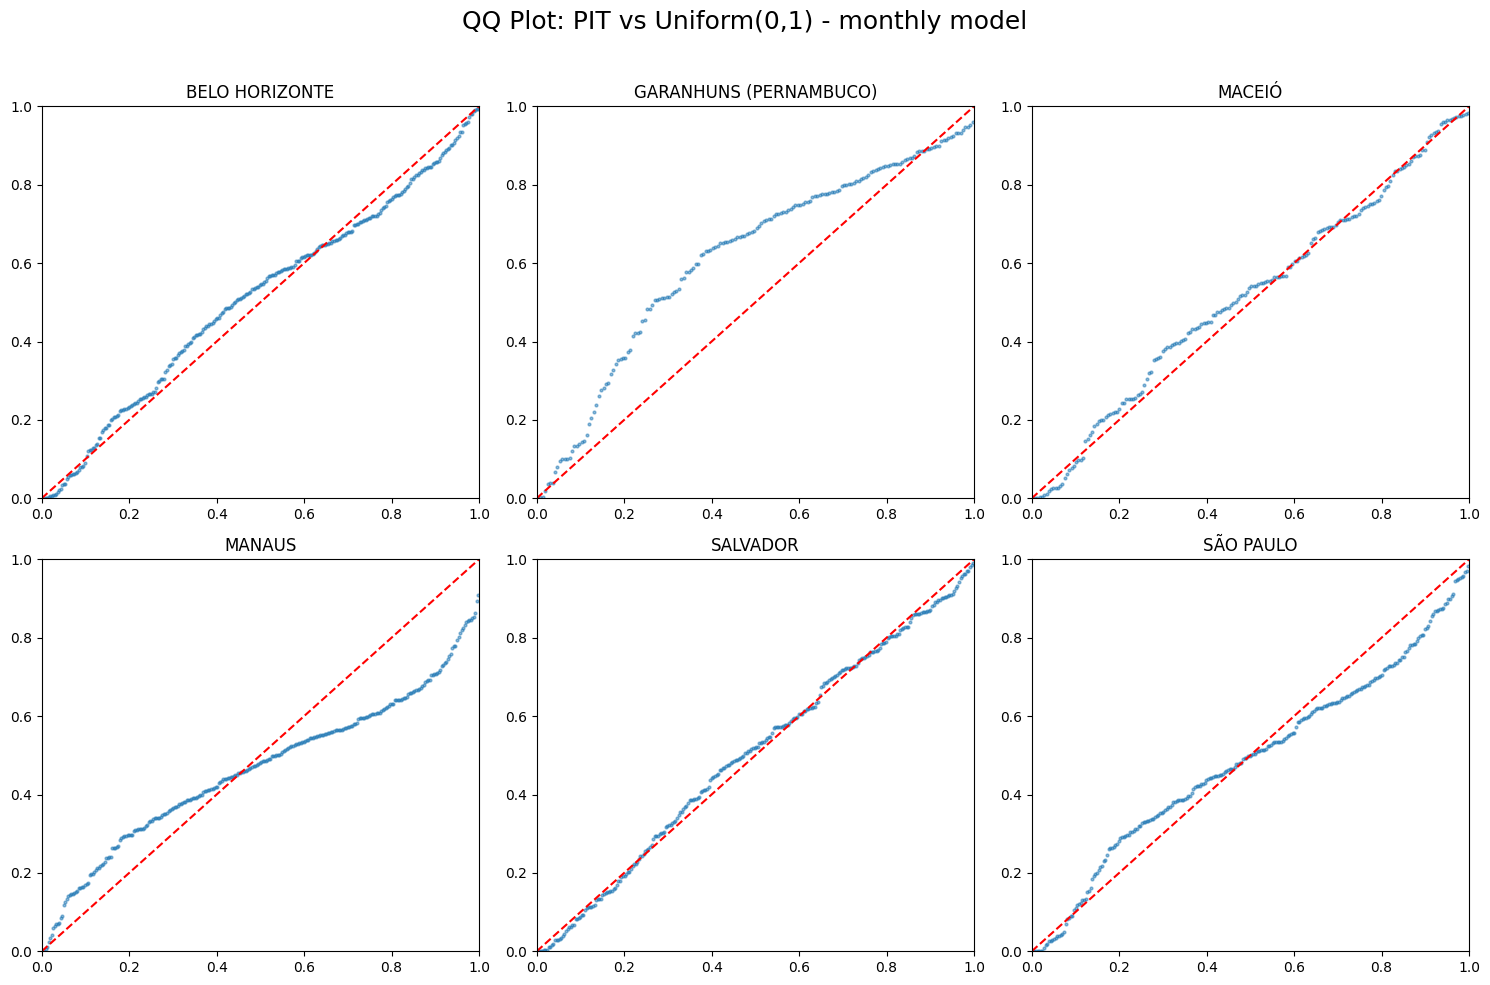

In [241]:
import math
import matplotlib.pyplot as plt

n_models = len(results)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
axes = axes.flatten()

for ax in axes[n_models:]:
    ax.axis("off")

for idx_plot, (k, result) in enumerate(results.items()):

    ax = axes[idx_plot]
    res = result[0]

    # --- (your parameter extraction block stays the same) ---
    # assume pit already computed exactly as in your code

    pit_sorted = np.sort(pits[idx_plot])
    n = len(pit_sorted)
    u_theoretical = (np.arange(1, n+1) - 0.5) / n

    ax.plot(u_theoretical, pit_sorted, 'o', alpha=0.5, markersize=2)
    ax.plot([0,1], [0,1], 'r--')
    ax.set_title(k)
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

fig.suptitle("QQ Plot: PIT vs Uniform(0,1) - monthly model", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("QQ_PIT_mosaic_monthly.png", dpi=300)
plt.show()


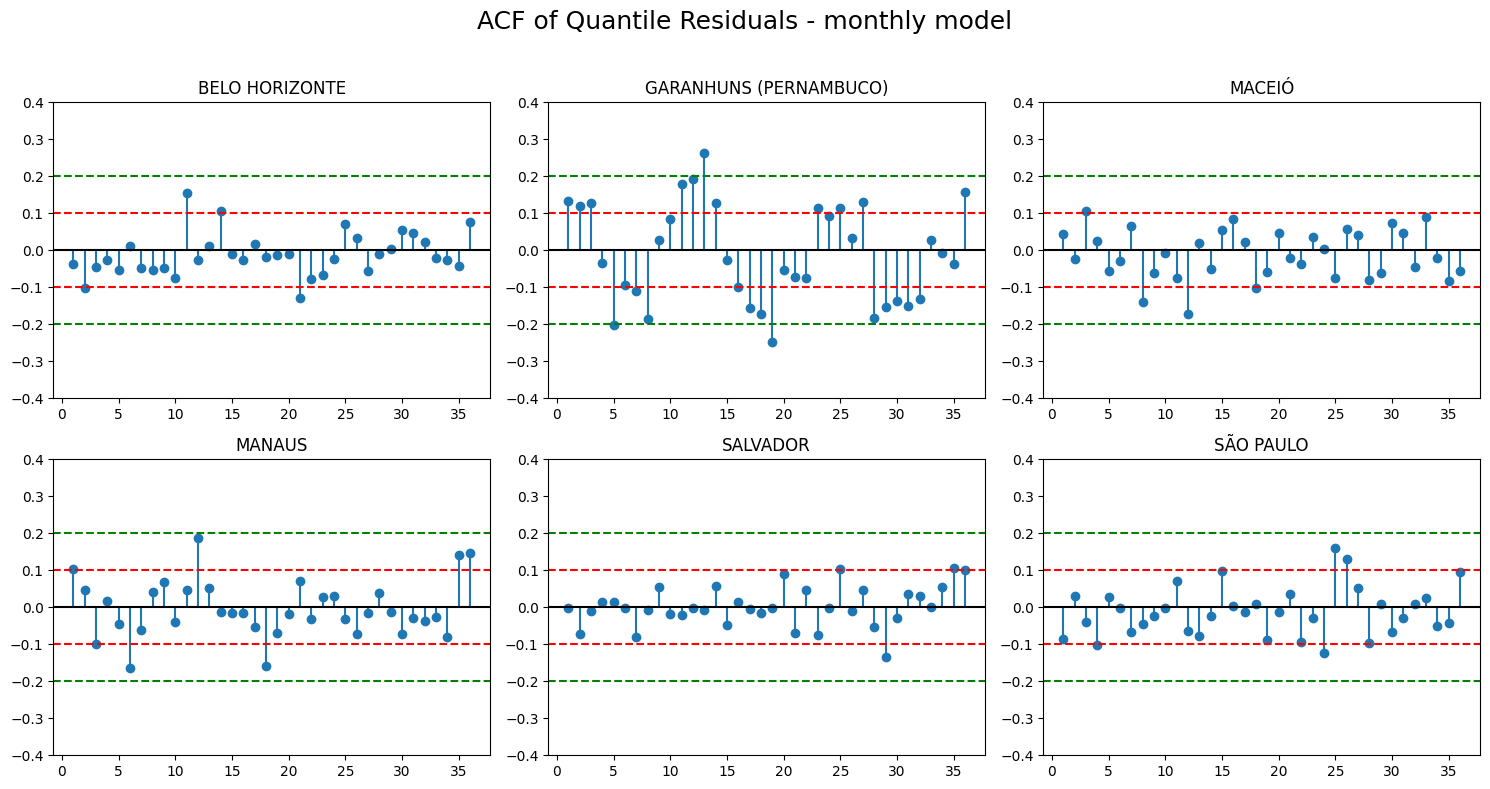

In [243]:
from statsmodels.tsa.stattools import acf

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax in axes[n_models:]:
    ax.axis("off")

for idx_plot, (k, result) in enumerate(results.items()):

    ax = axes[idx_plot]

    qr = quant[idx_plot]  # stored earlier

    nlags = 36  # 400 too crowded in mosaic
    acf_vals = acf(qr, nlags=nlags, fft=True)
    acf_vals_no0 = acf_vals[1:]
    lags = np.arange(1, nlags+1)
    
    conf01 = 0.1
    conf02 = 0.2

    ax.stem(lags, acf_vals_no0, basefmt=" ")
    ax.axhline(0, color="black")
    ax.axhline(conf01, color="red", linestyle="--")
    ax.axhline(-conf01, color="red", linestyle="--")
    ax.axhline(conf02, color="green", linestyle="--")
    ax.axhline(-conf02, color="green", linestyle="--")

    ax.set_title(k)
    ax.set_ylim(-0.4, 0.4)

fig.suptitle("ACF of Quantile Residuals - monthly model", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("ACF_quantile_mosaic_monthly.png", dpi=300)
plt.show()


In [129]:
new_df = dfs[0].groupby('year-month')['precipitation original'].sum()

In [130]:
new_df.to_csv(os.path.join(OUTPUT, 'precipitation_monthly_test_train.csv'), index = False)

In [131]:
new_df

year-month
2000-01    469.5
2000-02    194.0
2000-03    131.4
2000-04     55.1
2000-05      1.5
           ...  
2023-08     31.0
2023-09     15.8
2023-10    163.9
2023-11    113.9
2023-12    158.3
Name: precipitation original, Length: 288, dtype: float64